# PHISHING WEBSITES CLASSIFICATION - DECISION TREE
## Dataset: UCI Phishing Websites Dataset
## 30 Features | Binary Classification (Legitimate vs Phishing)

## 1. OBJECTIVES (Business Understanding) - 4 marks

### 1.1 Business Problem
Phishing websites are a critical cybersecurity threat used to steal sensitive user information. Automated detection systems can help prevent attacks and protect users from malicious websites.

### 1.2 Classification Task
- **Target Variable**: Website classification (Legitimate = -1, Phishing = 1)
- **Problem Type**: Binary Classification
- **Features**: 30 URL and domain-based indicators
- **Goal**: Build Decision Tree model to accurately detect phishing websites


## 2. DATA EXPLORATION (Data Understanding & Preparation) - 4 marks

### 2.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, 
    recall_score, f1_score, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 2.2 Load Dataset

In [3]:
df = pd.read_csv('/Users/adarsh/Phishing Websites Classification Project/phishing-classification/data/phishing_data.csv')
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset Shape: (11055, 31)

First 5 rows:
   having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0                 -1           1                   1                 1   
1                  1           1                   1                 1   
2                  1           0                   1                 1   
3                  1           0                   1                 1   
4                  1           0                  -1                 1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   Domain_registeration_le

### 2.3 Data Overview

In [4]:
print(f"Data Types:")
print(df.dtypes)
print(f"\n\nMissing Values:")
print(df.isnull().sum().sum())
print(f"\nDataset Info:")
print(df.info())

Data Types:
having_IP_Address              int64
URL_Length                     int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        int64
port                           int64
HTTPS_token                    int64
Request_URL                    int64
URL_of_Anchor                  int64
Links_in_tags                  int64
SFH                            int64
Submitting_to_email            int64
Abnormal_URL                   int64
Redirect                       int64
on_mouseover                   int64
RightClick                     int64
popUpWidnow                    int64
Iframe                         int64
age_of_domain                  int64
DNSRecord                      int64
web_traffic                    int64
Page_Rank                 

### 2.4 Target Variable Distribution

In [5]:
target_col = df.columns[-1]
print(f"Target Variable: {target_col}")
print(f"\nClass Distribution:")
print(df[target_col].value_counts())
print(f"\nClass Proportions:")
print(df[target_col].value_counts(normalize=True))

Target Variable: Result

Class Distribution:
Result
 1    6157
-1    4898
Name: count, dtype: int64

Class Proportions:
Result
 1    0.556943
-1    0.443057
Name: proportion, dtype: float64


### 2.5 Descriptive Statistics

In [6]:
print(df.describe())

       having_IP_Address    URL_Length  Shortining_Service  having_At_Symbol  \
count       11055.000000  11055.000000        11055.000000      11055.000000   
mean            0.313795     -0.633198            0.738761          0.700588   
std             0.949534      0.766095            0.673998          0.713598   
min            -1.000000     -1.000000           -1.000000         -1.000000   
25%            -1.000000     -1.000000            1.000000          1.000000   
50%             1.000000     -1.000000            1.000000          1.000000   
75%             1.000000     -1.000000            1.000000          1.000000   
max             1.000000      1.000000            1.000000          1.000000   

       double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  \
count              11055.000000   11055.000000       11055.000000   
mean                   0.741474      -0.734962           0.063953   
std                    0.671011       0.678139           0.817518   
min

### 2.6 Feature Preparation

In [7]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(f"Features Shape: {X.shape}")
print(f"Target Shape: {y.shape}")
print(f"\nFeature Names:")
print(list(X.columns))

Features Shape: (11055, 30)
Target Shape: (11055,)

Feature Names:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']


### 2.7 Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set Size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test Set Size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining Set Class Distribution:")
print(y_train.value_counts())
print(f"\nTest Set Class Distribution:")
print(y_test.value_counts())

Training Set Size: 8844 (80.0%)
Test Set Size: 2211 (20.0%)

Training Set Class Distribution:
Result
 1    4926
-1    3918
Name: count, dtype: int64

Test Set Class Distribution:
Result
 1    1231
-1     980
Name: count, dtype: int64


## 3. MODELING - 4 marks

### 3.1 Build Decision Tree Model

In [9]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5
)

dt_model.fit(X_train, y_train)
print("Decision Tree Model Trained")

Decision Tree Model Trained


### 3.2 Model Information

In [10]:
print("="*60)
print("DECISION TREE MODEL INFORMATION")
print("="*60)
print(f"Tree Depth: {dt_model.get_depth()}")
print(f"Number of Leaves: {dt_model.get_n_leaves()}")
print(f"Number of Features: {dt_model.n_features_in_}")
print(f"Classes: {dt_model.classes_}")

DECISION TREE MODEL INFORMATION
Tree Depth: 10
Number of Leaves: 159
Number of Features: 30
Classes: [-1  1]


### 3.3 Feature Importance

In [11]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 Important Features:")
print(feature_importance.head(15).to_string())

Top 15 Important Features:
                        Feature  Importance
7                SSLfinal_State    0.694656
13                URL_of_Anchor    0.123127
14                Links_in_tags    0.032847
25                  web_traffic    0.026961
6             having_Sub_Domain    0.026292
5                 Prefix_Suffix    0.017579
8   Domain_registeration_length    0.014846
28       Links_pointing_to_page    0.013591
15                          SFH    0.006900
23                age_of_domain    0.006368
27                 Google_Index    0.006331
1                    URL_Length    0.005822
12                  Request_URL    0.005442
24                    DNSRecord    0.004908
9                       Favicon    0.003022


### 3.4 Feature Importance Visualization

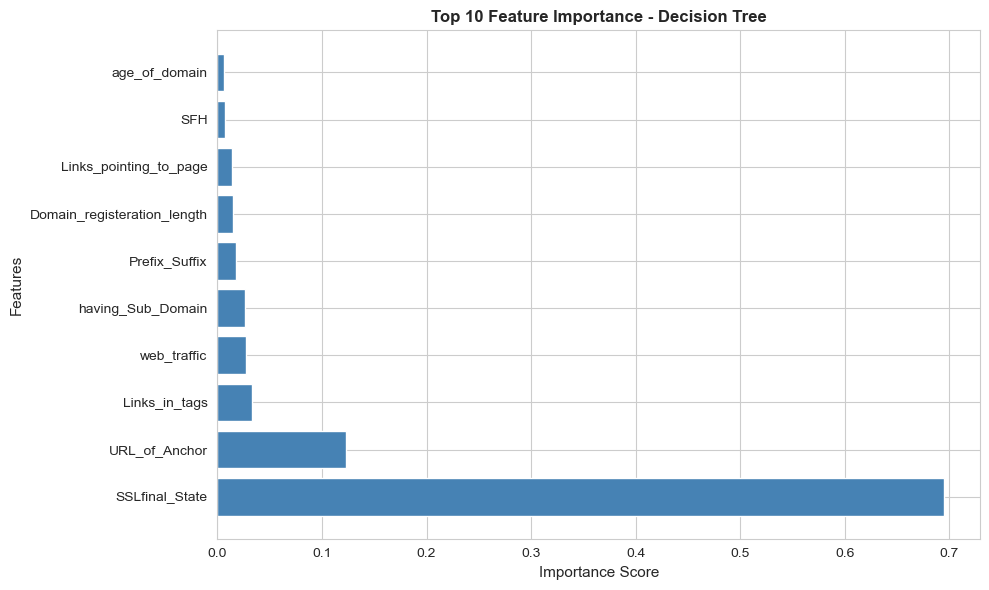

Feature importance plot saved


In [26]:
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.title('Top 10 Feature Importance - Decision Tree', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/adarsh/Phishing Websites Classification Project/phishing-classification/plots/dt_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Feature importance plot saved")

### 3.5 Tree Structure Visualization

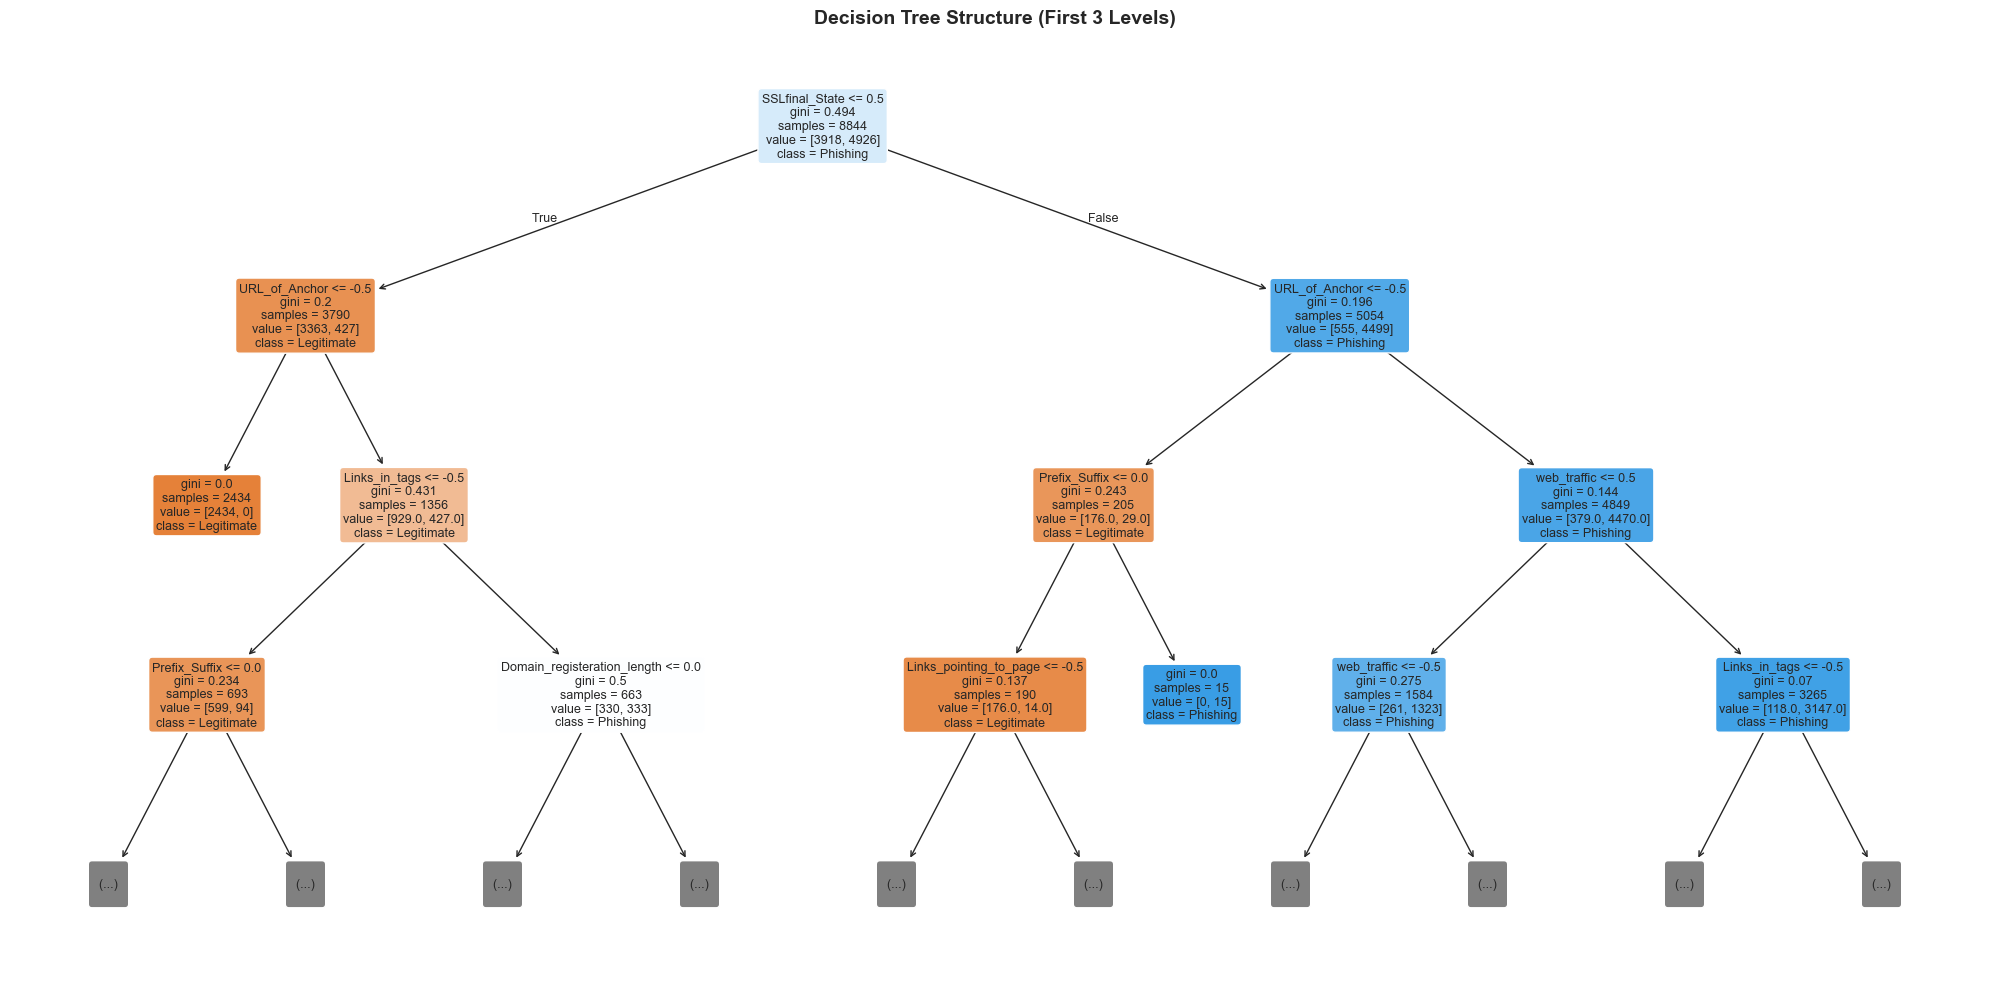

Tree structure saved


In [16]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=list(X.columns),
          class_names=['Legitimate', 'Phishing'],
          filled=True,
          rounded=True,
          fontsize=9,
          max_depth=3)
plt.title('Decision Tree Structure (First 3 Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/adarsh/Phishing Websites Classification Project/phishing-classification/plots/dt_tree_structure.png', dpi=300, bbox_inches='tight')
plt.show()
print("Tree structure saved")

### 3.6 Cross-Validation

In [17]:
cv_scores = cross_val_score(
    dt_model, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)

print("5-Fold Cross-Validation Results:")
print(f"Fold Scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

5-Fold Cross-Validation Results:
Fold Scores: ['0.9384', '0.9389', '0.9367', '0.9463', '0.9406']
Mean CV Accuracy: 0.9402
Std Dev: 0.0033


## 4. EVALUATION & CONCLUSION - 4 marks

### 4.1 Predictions

In [18]:
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

print("Predictions generated for training and test sets")

Predictions generated for training and test sets


### 4.2 Training Set Performance

In [19]:
print("="*60)
print("TRAINING SET PERFORMANCE")
print("="*60)
train_acc = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred)
train_rec = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

print(f"Accuracy:  {train_acc:.4f}")
print(f"Precision: {train_prec:.4f}")
print(f"Recall:    {train_rec:.4f}")
print(f"F1-Score:  {train_f1:.4f}")

TRAINING SET PERFORMANCE
Accuracy:  0.9532
Precision: 0.9593
Recall:    0.9566
F1-Score:  0.9579


### 4.3 Test Set Performance

In [20]:
print("="*60)
print("TEST SET PERFORMANCE")
print("="*60)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-Score:  {test_f1:.4f}")

TEST SET PERFORMANCE
Accuracy:  0.9403
Precision: 0.9449
Recall:    0.9480
F1-Score:  0.9465


### 4.4 Confusion Matrix

In [21]:
cm_test = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix (Test Set):")
print(cm_test)
print(f"\nTrue Negatives:  {cm_test[0,0]}")
print(f"False Positives: {cm_test[0,1]}")
print(f"False Negatives: {cm_test[1,0]}")
print(f"True Positives:  {cm_test[1,1]}")

Confusion Matrix (Test Set):
[[ 912   68]
 [  64 1167]]

True Negatives:  912
False Positives: 68
False Negatives: 64
True Positives:  1167


### 4.5 Confusion Matrix Visualization

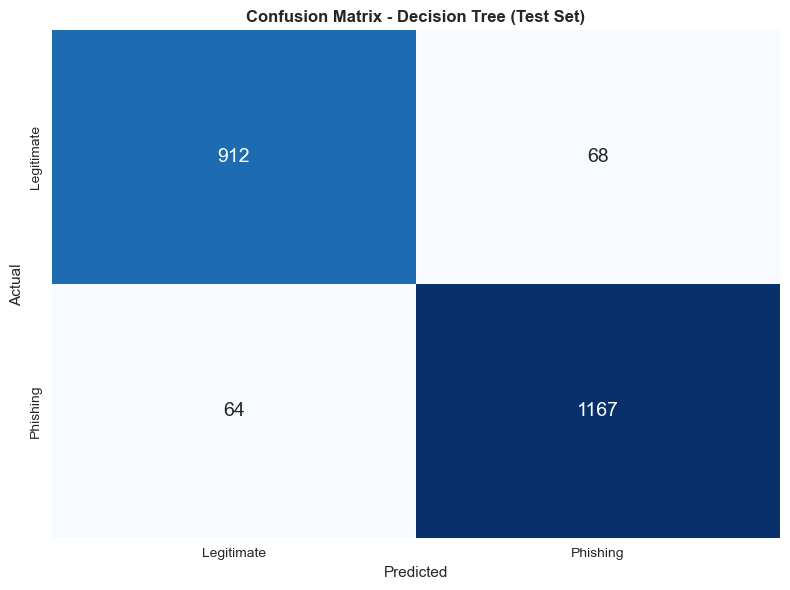

Confusion matrix plot saved


In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'],
            cbar=False, annot_kws={'size': 14})
plt.title('Confusion Matrix - Decision Tree (Test Set)', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=11)
plt.xlabel('Predicted', fontsize=11)
plt.tight_layout()
plt.savefig('/Users/adarsh/Phishing Websites Classification Project/phishing-classification/plots/dt_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrix plot saved")

### 4.6 Classification Report

In [23]:
print("\nDetailed Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, 
                          target_names=['Legitimate', 'Phishing']))


Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

  Legitimate       0.93      0.93      0.93       980
    Phishing       0.94      0.95      0.95      1231

    accuracy                           0.94      2211
   macro avg       0.94      0.94      0.94      2211
weighted avg       0.94      0.94      0.94      2211



### 4.7 Conclusion & Interpretation

In [24]:
print("="*70)
print("DECISION TREE - CONCLUSION & INTERPRETATION")
print("="*70)

print(f"""
MODEL PERFORMANCE SUMMARY:
  • Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)
  • Precision: {test_prec:.4f} - When predicting phishing, correct {test_prec*100:.1f}% of the time
  • Recall: {test_rec:.4f} - Catches {test_rec*100:.1f}% of actual phishing websites
  • F1-Score: {test_f1:.4f}
  • Cross-Validation Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})

TOP 3 IMPORTANT FEATURES:
  1. {feature_importance.iloc[0]['Feature']} ({feature_importance.iloc[0]['Importance']:.4f})
  2. {feature_importance.iloc[1]['Feature']} ({feature_importance.iloc[1]['Importance']:.4f})
  3. {feature_importance.iloc[2]['Feature']} ({feature_importance.iloc[2]['Importance']:.4f})

INTERPRETATION:
The Decision Tree model achieves {test_acc*100:.2f}% accuracy on the test set. 
With {test_rec*100:.1f}% recall, the model effectively identifies phishing websites.
The precision of {test_prec*100:.1f}% indicates good specificity with minimal false alarms.
Cross-validation score of {cv_scores.mean():.4f} shows the model generalizes well.
""")

DECISION TREE - CONCLUSION & INTERPRETATION

MODEL PERFORMANCE SUMMARY:
  • Test Accuracy: 0.9403 (94.03%)
  • Precision: 0.9449 - When predicting phishing, correct 94.5% of the time
  • Recall: 0.9480 - Catches 94.8% of actual phishing websites
  • F1-Score: 0.9465
  • Cross-Validation Accuracy: 0.9402 (±0.0033)

TOP 3 IMPORTANT FEATURES:
  1. SSLfinal_State (0.6947)
  2. URL_of_Anchor (0.1231)
  3. Links_in_tags (0.0328)

INTERPRETATION:
The Decision Tree model achieves 94.03% accuracy on the test set. 
With 94.8% recall, the model effectively identifies phishing websites.
The precision of 94.5% indicates good specificity with minimal false alarms.
Cross-validation score of 0.9402 shows the model generalizes well.



### 4.8 Save Model

In [25]:
with open('/Users/adarsh/Phishing Websites Classification Project/phishing-classification/models/decision_tree_model.pkl', 'wb') as f:
    pickle.dump(dt_model, f)

print("Model saved to models/decision_tree_model.pkl")

Model saved to models/decision_tree_model.pkl
